# Week 1 — Run it, then discover a real truth yourself

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Sujan-lab-cell/flyrank-ml-internship/blob/main/notebooks/01_first_look_and_discovery.ipynb?flush_cache=true)

By the end of this notebook you will have:
1. **Run a real ML pipeline** on real (anonymized) search data and watched a learned model beat a hand-written rule.
2. **Rediscovered a real finding yourself** in ~10 lines of pandas.

No prior ML needed. Everything runs on the small anonymized dataset that ships with this repo — no credentials, no private data.

## 0. Setup (Colab or local)
On Colab this clones the repo and installs requirements. Locally it just moves to the repo root.

In [5]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
else:
    # find the repo root from wherever this kernel started
    while not os.path.isdir("data/raw") and os.getcwd() != "/":
        os.chdir("..")

print("Working dir:", os.getcwd())
assert os.path.exists("data/raw/content_refresh_anonymized.csv"), "starter CSV not found — are you at the repo root?"
print("Starter data found. You're ready.")

Working dir: /content/flyrank-ml-internship-starter
Starter data found. You're ready.


## 1. Run the whole pipeline

This runs `scripts/run_all.py`: prepare features → baseline rule → train 3 models → evaluate → PDF.
It takes ~1 minute on the 30,000-row sample.

In [6]:
# Watch it work — each of the 5 steps prints live as it runs (~1 minute total).
!{sys.executable} scripts/run_all.py



▶ Step 1/5 — Prepare features — clean the data, build the feature vector, define the label
Prepared 30,000 rows from 30,000 raw rows
Wrote /content/flyrank-ml-internship-starter/data/processed/refresh_feature_vector.csv

▶ Step 2/5 — Baseline — a transparent hand-written rule to beat
Wrote baseline queue: /content/flyrank-ml-internship-starter/data/processed/baseline_refresh_queue.csv
Top-50 declining rate (full data, not the evaluated holdout Precision@50): 0.340

▶ Step 3/5 — Train — logistic regression, decision tree, random forest (client-holdout split)
Trained 3 models on 30,000 rows
Split strategy: client_holdout
Best model: random_forest
Wrote predictions: /content/flyrank-ml-internship-starter/data/processed/model_predictions.csv
Wrote model results: /content/flyrank-ml-internship-starter/outputs/model_results.json

▶ Step 4/5 — Evaluate — ranked refresh queue, charts, and the Markdown report
Wrote final refresh queue: /content/flyrank-ml-internship-starter/outputs/refresh_que

### What just happened?
The pipeline ranked every page for "refresh review" two ways: a **hand-written rule baseline** and a **learned model**. Let's compare them on **Precision@50** — of the top 50 pages each says to fix first, how many are actually declining?

In [7]:
import json
res = json.load(open("outputs/model_results.json"))

base = res["baseline"]["baseline_precision_at_50"]
rf   = res["models"]["random_forest"]["precision_at_50"]

print(f"Hand-written rule  Precision@50: {base:.3f}   (~{round(base*50)} of the top 50 right)")
print(f"Random forest      Precision@50: {rf:.3f}   (~{round(rf*50)} of the top 50 right)")
print(f"\nThe learned model roughly {rf/base:.1f}x the rule on this metric.")
print("Validation split used:", res["split_strategy"], "(pages from a client are never in both train and test)")

Hand-written rule  Precision@50: 0.240   (~12 of the top 50 right)
Random forest      Precision@50: 0.740   (~37 of the top 50 right)

The learned model roughly 3.1x the rule on this metric.
Validation split used: client_holdout (pages from a client are never in both train and test)


You just ran a real ML system on real search data and saw a learned ranking beat a fixed rule. Now open `outputs/model_report.md` and skim it — that Markdown report is the *shape* of what your own capstone should produce.

## 2. Discover a real truth yourself

The safest, most satisfying early wins are **things you find in the data** — un-leakable, and they *are* the core lesson. Run the three cells below. Each is ~10 lines of pandas and each overturns a common SEO belief.

Every number is **computed live from the shipped CSV** — nothing is hardcoded.

In [8]:
import pandas as pd, numpy as np
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
print(df.shape[0], "rows,", df.shape[1], "columns")
df.head(3)

30000 rows, 44 columns


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9


### Discovery A — "High search volume means more traffic." Does it?

In [9]:
corr = df["search_volume"].corr(df["impressions_90d"])
print(f"Correlation between search_volume and impressions_90d: {corr:.3f}")
print("Near zero -> keyword search volume barely predicts the traffic a page actually gets.")

Correlation between search_volume and impressions_90d: 0.001
Near zero -> keyword search volume barely predicts the traffic a page actually gets.


### Discovery B — the CTR cliff by position
Click-through rate is not flat: it collapses as you move down the results.

position_tier
page_1      0.3548
top_3       0.3341
striking    0.2558
page_3_5    0.1424
deep        0.0554


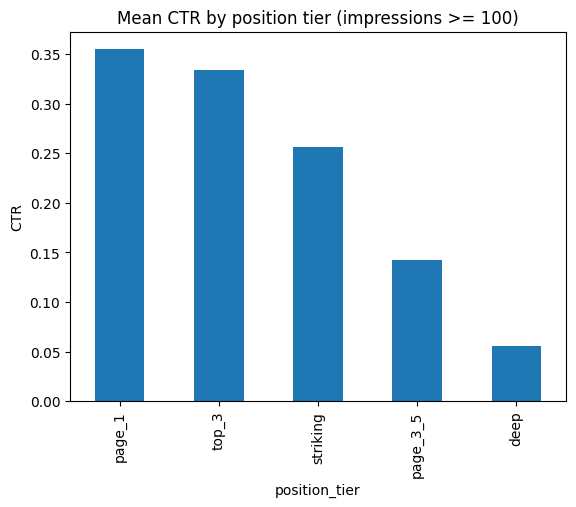

In [10]:
visible = df[df["impressions_90d"] >= 100]
ctr_by_pos = visible.groupby("position_tier")["ctr"].mean().sort_values(ascending=False)
print(ctr_by_pos.round(4).to_string())
ctr_by_pos.plot(kind="bar", title="Mean CTR by position tier (impressions >= 100)", ylabel="CTR");

### Discovery C — is longer content the lever?
Compare word count for **declining** vs **growing** pages.

In [11]:
wc = df.groupby("trend_direction")["word_count"].median()
print(wc.round(0).to_string())
print("\n'down' vs 'up' pages have almost the same median word count -> length is not the lever.")

trend_direction
down      2909.0
flat      2698.0
new       2239.0
stable    2912.0
up        2848.0

'down' vs 'up' pages have almost the same median word count -> length is not the lever.


## 3. 🔧 Your turn

Pick **one** of these and write a few lines below. This is your Week-1 discovery — you'll reference it in your Week-1 research-question write-up (on the InternHQ board).

- Redo Discovery A but only for pages with `impressions_90d > 0` — does the correlation change?
- In Discovery B, which `content_type` has the worst CTR *at the same position tier*?
- Find another belief to test: does `content_age_days` relate to `trend_direction`? Does `avg_position` relate to `ctr`?

**Rules:** describe what you observe as *observed / directional* — never "I proved Google's algorithm." Keep client data out of anything you publish.

## Investigation 1: Does Content Age Relate to Declining Trends?

### Question

Are older content pages more likely to have a declining trend?

### Why am I checking this?

 For the Refresh / Content Opportunity Scoring lane, content age could potentially
be a useful signal for deciding which pages deserve human review.

I will compare the percentage of declining pages across different content-age groups.

This analysis shows an observed relationship only. It does not prove that older
content causes traffic to decline.


In [15]:
# Create age groups
df["age_group"] = pd.cut(
    df["content_age_days"],
    bins=[0, 90, 180, 365, float("inf")],
    labels=["0-90 days", "91-180 days", "181-365 days", "365+ days"]
)

# Calculate percentage of pages that are declining
age_analysis = (
    df.groupby("age_group", observed=True)["trend_direction"]
      .apply(lambda x: (x == "down").mean() * 100)
      .reset_index(name="declining_percentage")
)

age_analysis

,age_group,declining_percentage
0,0-90 days,66.869919
1,91-180 days,62.555178
2,181-365 days,51.486629
3,365+ days,42.625786


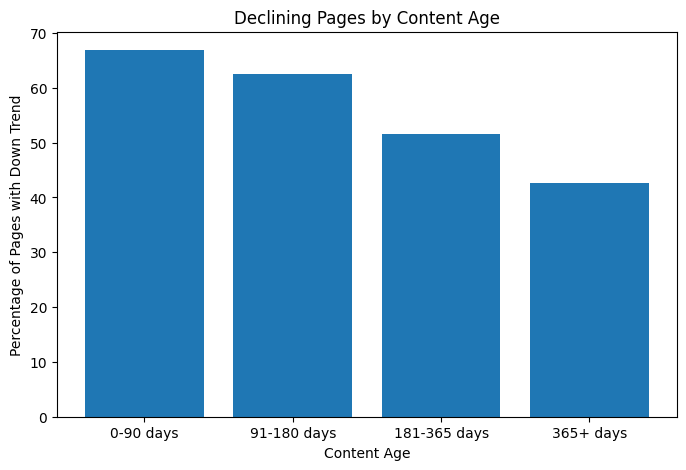

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    age_analysis["age_group"],
    age_analysis["declining_percentage"]
)

plt.xlabel("Content Age")
plt.ylabel("Percentage of Pages with Down Trend")
plt.title("Declining Pages by Content Age")

plt.show()

### Observation

The results show that newer content has a higher percentage of pages with a
`down` trend than older content.

Pages aged 0–90 days had the highest proportion of declining trends at
66.87%, while pages older than 365 days had the lowest proportion at 42.63%.

This is the opposite of the initial expectation that older content would be
more likely to decline.

This suggests that content age alone may not be a strong reason to prioritize
older pages for refresh in this dataset. The relationship is observational and
does not establish that content age causes changes in performance.

## Investigation 2: Content Age + Content Type + Trend

### Question

Does the relationship between content age and declining trends differ by content type?

### Why am I checking this?

Content age alone may not tell us whether a page is a good refresh candidate.
Different content types may behave differently as they age.

I will therefore compare the percentage of declining pages across different
content-age groups separately for each content type.

This analysis measures an observed relationship. It does not prove that content
age or content type causes a page to decline.

In [22]:
df["age_group"] = pd.cut(
    df["content_age_days"],
    bins=[0, 90, 180, 365, float("inf")],
    labels=["0-90 days", "91-180 days", "181-365 days", "365+ days"]
)

In [23]:
age_type_analysis = (
    df.groupby(["content_type", "age_group"], observed=True)["trend_direction"]
      .apply(lambda x: (x == "down").mean() * 100)
      .reset_index(name="declining_percentage")
)

age_type_analysis

,content_type,age_group,declining_percentage
0,comparison article,91-180 days,63.756614
1,comparison article,181-365 days,49.529781
2,feedly article,0-90 days,54.545455
3,feedly article,91-180 days,21.555916
4,feedly article,181-365 days,31.471390
5,keyword article,0-90 days,67.151767
6,keyword article,91-180 days,64.858600
7,keyword article,181-365 days,54.618516
8,keyword article,365+ days,42.625786


In [24]:
age_type_pivot = age_type_analysis.pivot(
    index="age_group",
    columns="content_type",
    values="declining_percentage"
)

age_type_pivot

content_type,comparison article,feedly article,keyword article
age_group,,,
0-90 days,NaN,54.545455,67.151767
91-180 days,63.756614,21.555916,64.858600
181-365 days,49.529781,31.471390,54.618516
365+ days,NaN,NaN,42.625786


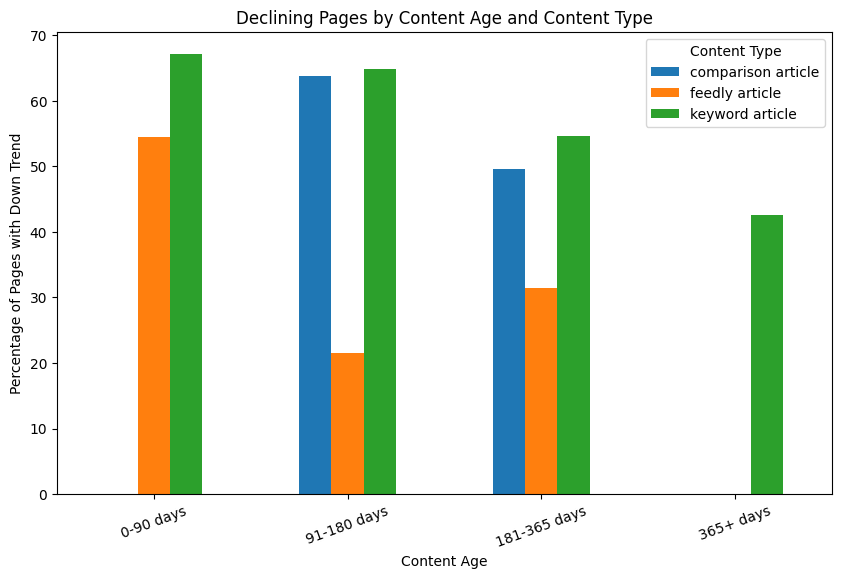

In [25]:
age_type_pivot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("Content Age")
plt.ylabel("Percentage of Pages with Down Trend")
plt.title("Declining Pages by Content Age and Content Type")
plt.xticks(rotation=20)
plt.legend(title="Content Type")

plt.show()

In [26]:
age_type_counts = (
    df.groupby(["content_type", "age_group"], observed=True)
      .size()
      .reset_index(name="page_count")
)

age_type_counts

,content_type,age_group,page_count
0,comparison article,91-180 days,378
1,comparison article,181-365 days,319
2,feedly article,0-90 days,11
3,feedly article,91-180 days,617
4,feedly article,181-365 days,1468
5,keyword article,0-90 days,481
6,keyword article,91-180 days,10785
7,keyword article,181-365 days,9581
8,keyword article,365+ days,6360


In [27]:
age_type_summary = age_type_analysis.merge(
    age_type_counts,
    on=["content_type", "age_group"]
)

age_type_summary

,content_type,age_group,declining_percentage,page_count
0,comparison article,91-180 days,63.756614,378
1,comparison article,181-365 days,49.529781,319
2,feedly article,0-90 days,54.545455,11
3,feedly article,91-180 days,21.555916,617
4,feedly article,181-365 days,31.471390,1468
5,keyword article,0-90 days,67.151767,481
6,keyword article,91-180 days,64.858600,10785
7,keyword article,181-365 days,54.618516,9581
8,keyword article,365+ days,42.625786,6360


### Observation

The relationship between content age and declining trends appears to differ
across content types.

For keyword articles, the percentage of pages with a `down` trend decreases
as content age increases, from 67.15% for pages aged 0–90 days to 42.63% for
pages older than 365 days.

Comparison articles also show a decrease from 63.76% for pages aged 91–180
days to 49.53% for pages aged 181–365 days.

Feedly articles do not show the same clear pattern. The 0–90 day group has a
54.55% declining rate, but it contains only 11 pages, so this result should be
interpreted cautiously. The 91–180 day group has a 21.56% declining rate, while
the 181–365 day group has a 31.47% declining rate. There is no 365+ day group
for Feedly articles in this dataset.

Some age and content-type combinations have no observations, so they are shown
as missing rather than being treated as zero.

Newer content has a higher percentage of pages with a declining trend in this
dataset. This pattern is especially clear for keyword articles, where the
declining percentage decreases from 67.15% for 0–90 day-old pages to 42.63%
for pages older than 365 days.

This is an observed relationship and does not mean that newer content causes
declining performance.

### Save your work
**Colab:** *File → Save a copy in GitHub* (writes to your own repo — that's your submission) and *File → Save a copy in Drive* (so the session doesn't evaporate).

Next: `02_your_first_readable_model.ipynb` — where the model becomes a rule you can read.